<a href="https://colab.research.google.com/github/limaslucas/limaslucas/blob/main/MVP%20%7C%20An%C3%A1lise%20de%20Dados%20e%20Boas%20Pr%C3%A1ticas%20%7C%20Lucas%20Lima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Lima

**Matrícula:** 4052025002631

**Dataset:** Onco-360 via API do Kaggle (https://www.kaggle.com/datasets/rafatrindade/onco-360)


# Descrição do Problema

O objetivo deste projeto é analisar o tempo decorrido entre o diagnóstico de câncer e o início do primeiro tratamento no Hospital São Francisco (Belo Horizonte), verificando a adesão à Lei nº 12.732/12 (Lei dos 60 Dias). A análise busca identificar gargalos no fluxo de atendimento que possam atrasar o início terapêutico, impactando o prognóstico dos pacientes

## Hipóteses do Problema

Para análise exploratória e a criação dos gráficos obrigatórios, utilizei estas três hipóteses:

1. Hipótese 1: Pacientes diagnosticados em estágios mais avançados (Estadiamento III e IV) apresentam um tempo de início de tratamento menor (priorização) em comparação aos estágios iniciais.

2. Hipótese 2: Modalidades de tratamento combinadas (Quimioterapia + Radioterapia) apresentam um tempo de espera maior para o início do que modalidades únicas, como apenas Cirurgia.

3. Hipótese 3: Mais de 80% dos pacientes atendidos no Hospital São Francisco iniciam o tratamento dentro do prazo legal de 60 dias após o diagnóstico.

## Tipo de Problema

Trata-se de um problema de Análise Exploratória Descritiva, com ênfase em conformidade regulatória.

## Seleção de Dados

Para este MVP, utilizou-se o dataset Onco-360, acessado via API do kagglehub. O conjunto de dados selecionado especificamente foi o raw_painel_de_oncologia.parquet, que consiste na base bruta do Painel de Oncologia do SUS.

## Atributos do Dataset

* **cnes_trat:** Identifica o código do estabelecimento de saúde onde
foi realizado o primeiro tratamento.

* **tempo_trat:** Identifica o intervalo de tempo transcorrido entre o diagnóstico e o início do tratamento.

* **ano_diagn:** Identifica o ano em que o diagnóstico da neoplasia foi realizado.

* **estadiam:** Identifica o estágio de desenvolvimento da doença no momento do diagnóstico.

* **idade:** Identifica a idade do paciente no momento em que o diagnóstico foi registrado.

* **sexo:** Identifica o sexo biológico do paciente.

* **tratamento:** Identifica a modalidade do primeiro tratamento recebido (ex: cirurgia, quimioterapia ou radioterapia).

* **diag_deth:** Identifica o diagnóstico detalhado da doença através da codificação CID-10.

* **dt_diag:** Identifica a data completa em que o diagnóstico foi estabelecido.

* **dt_trat:** Identifica a data completa em que o primeiro tratamento foi iniciado.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida as importações das bibliotecas necessárias para análise e visualização, além de realizar o carregamento automatizado do dataset Onco-360 via API do Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Download da versão mais recente do dataset Onco-360
path = kagglehub.dataset_download("rafatrindade/onco-360")
caminho_arquivo = os.path.join(path, 'raw_painel_de_oncologia.parquet')

100%|██████████| 1.32G/1.32G [00:17<00:00, 79.9MB/s]

Extracting files...


In [2]:
# Guardando o dataset em um dataframe
df = pd.read_parquet(caminho_arquivo)

# Exibindo as primeiras linhas
df.head()

,ANOMES_DIA,ANOMES_TRA,ANO_DIAGN,ANO_TRATAM,CNES_DIAG,CNES_TRAT,CNS_PAC,DIAGNOSTIC,DIAG_DETH,DT_DIAG,...,IDADE,MUN_DIAG,MUN_RESID,MUN_TRATAM,SEXO,TEMPO_TRAT,TRATAMENTO,UF_DIAGN,UF_RESID,UF_TRATAM
0,201308,201411,2013,2014,2077477,2077477,,01,C61,27/08/2013,...,074,355030,355030,355030,M,+0457,2,35,35,35
1,201307,201306,2013,2013,2080125,2078287,,01,C54,23/07/2013,...,071,355030,355030,355030,F,-0031,1,35,35,35
2,201308,201401,2013,2014,2080532,2080532,,01,C80,30/08/2013,...,075,354140,351530,354140,M,+0137,2,35,35,35
3,201307,201308,2013,2013,2081458,2081458,,01,C18,03/07/2013,...,057,352690,352690,352690,F,+0051,2,35,35,35
4,201301,201304,2013,2013,2081695,2081695,,01,C50,31/01/2013,...,069,355220,355450,355220,F,+0068,2,35,35,35


# Pré-Processsamento de Dados

### Filtragem do Dataset para o Hospital São Francisco (2025)

Nesta etapa de pré-processamento, o dataset original `df` foi filtrado para atender aos critérios específicos da análise:

1.  **Ano de Diagnóstico (DT_DIAG):** Foram selecionados apenas os registros onde o diagnóstico ocorreu no ano de 2025. Isso garante que a análise se concentre nos dados mais recentes e relevantes para o período. A coluna `DT_DIAG` foi primeiramente convertida para o formato datetime para permitir a extração e comparação do ano.
2.  **CNES do Hospital (CNES_DIAG):** A filtragem foi aplicada para incluir somente os dados relacionados ao Hospital São Francisco, identificado pelo código CNES '0026840'.

O resultado desta filtragem é o novo DataFrame `df_2025`, que contém exclusivamente os dados de pacientes diagnosticados no Hospital São Francisco em 2025, conforme os critérios estabelecidos para a análise.

In [3]:
df['DT_DIAG'] = pd.to_datetime(df['DT_DIAG'], format='%d/%m/%Y', errors='coerce')
df_2025 = df[(df['DT_DIAG'].dt.year == 2025) & (df['CNES_DIAG'] == '0026840')]

In [4]:
print(f"O dataset filtrado para 2025 e CNES_DIAG '0026840' possui {df_2025.shape[0]} registros e {df_2025.shape[1]} colunas.")
display(df_2025.head())

O dataset filtrado para 2025 e CNES_DIAG '0026840' possui 737 registros e 23 colunas.


,ANOMES_DIA,ANOMES_TRA,ANO_DIAGN,ANO_TRATAM,CNES_DIAG,CNES_TRAT,CNS_PAC,DIAGNOSTIC,DIAG_DETH,DT_DIAG,...,IDADE,MUN_DIAG,MUN_RESID,MUN_TRATAM,SEXO,TEMPO_TRAT,TRATAMENTO,UF_DIAGN,UF_RESID,UF_TRATAM
4883978,202502,,2025,,0026840,,,01,C77,2025-02-06,...,048,310620,312980,,F,,5,31,31,
4884409,202505,202507,2025,2025,0026840,0026840,,01,C61,2025-05-15,...,066,310620,312980,310620,M,+0064,2,31,31,31
4884851,202501,,2025,,0026840,,,02,D04,2025-01-31,...,042,310620,310620,,M,99999,5,31,31,
4885043,202511,,2025,,0026840,,,02,D01,2025-11-04,...,064,310620,313190,,F,99999,5,31,31,
4885680,202504,202509,2025,2025,0026840,0026840,,01,C53,2025-04-02,...,052,310620,312090,310620,F,+0156,3,31,31,31


## Verificando os tipos de dados:

In [5]:
print("Tipos de dados por coluna em df_2025:")
print(df_2025.dtypes)

Tipos de dados por coluna em df_2025:
ANOMES_DIA            object
ANOMES_TRA            object
ANO_DIAGN             object
ANO_TRATAM            object
CNES_DIAG             object
CNES_TRAT             object
CNS_PAC               object
DIAGNOSTIC            object
DIAG_DETH             object
DT_DIAG       datetime64[ns]
DT_NASC               object
DT_TRAT               object
ESTADIAM              object
IDADE                 object
MUN_DIAG              object
MUN_RESID             object
MUN_TRATAM            object
SEXO                  object
TEMPO_TRAT            object
TRATAMENTO            object
UF_DIAGN              object
UF_RESID              object
UF_TRATAM             object
dtype: object


## Verificando células vazias:

In [6]:
print("Contagem de strings vazias ou apenas espaços em branco por coluna em df_2025:")
for col in df_2025.columns:
    if df_2025[col].dtype == 'object':
        empty_strings_count = df_2025[col].apply(lambda x: isinstance(x, str) and (x.strip() == '')).sum()
        if empty_strings_count > 0:
            print(f"Coluna '{col}': {empty_strings_count} ocorrências de strings vazias ou apenas espaços")
    elif df_2025[col].isnull().sum() > 0:
        print(f"Coluna '{col}': {df_2025[col].isnull().sum()} ocorrências de valores nulos (NaN)")

Contagem de strings vazias ou apenas espaços em branco por coluna em df_2025:
Coluna 'ANOMES_TRA': 441 ocorrências de strings vazias ou apenas espaços
Coluna 'ANO_TRATAM': 441 ocorrências de strings vazias ou apenas espaços
Coluna 'CNES_TRAT': 441 ocorrências de strings vazias ou apenas espaços
Coluna 'CNS_PAC': 737 ocorrências de strings vazias ou apenas espaços
Coluna 'DT_TRAT': 441 ocorrências de strings vazias ou apenas espaços
Coluna 'ESTADIAM': 47 ocorrências de strings vazias ou apenas espaços
Coluna 'MUN_TRATAM': 441 ocorrências de strings vazias ou apenas espaços
Coluna 'TEMPO_TRAT': 21 ocorrências de strings vazias ou apenas espaços
Coluna 'UF_TRATAM': 441 ocorrências de strings vazias ou apenas espaços


### Limpeza de Strings Vazias e Conversão de Tipos

Com base na análise anterior, onde identificamos strings vazias em diversas colunas, vamos proceder com a limpeza e conversão de tipos de dados. Os passos incluem a remoção de colunas com dados ausentes, a padronização de strings vazias para `np.nan` e a conversão de colunas críticas para o tipo apropriado.

In [7]:
import pandas as pd
import numpy as np

# 1. Remover a coluna 'CNS_PAC' que está completamente vazia
df_clean = df_2025.drop(columns=['CNS_PAC'])

# 2. Converter strings vazias ou com apenas espaços em branco para np.nan em todas as colunas 'object'
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].apply(lambda x: np.nan if isinstance(x, str) and x.strip() == '' else x)

# 3. Tratar a coluna 'IDADE': converter para numérico
df_clean['IDADE'] = pd.to_numeric(df_clean['IDADE'], errors='coerce')

# 4. Tratar a coluna 'TEMPO_TRAT': converter para numérico mantendo o sinal
df_clean['TEMPO_TRAT'] = pd.to_numeric(df_clean['TEMPO_TRAT'], errors='coerce')
# Renomear para clareza, pois a descrição fala em 'tempo_dias'
df_clean.rename(columns={'TEMPO_TRAT': 'tempo_dias'}, inplace=True)

# 5. Lidar com '99999.0' em 'tempo_dias' e obter o valor absoluto
# Substituir 99999.0 por NaN, pois indica dado ausente/inválido
df_clean['tempo_dias'] = df_clean['tempo_dias'].replace(99999.0, np.nan)
# Obter o valor absoluto
df_clean['tempo_dias'] = df_clean['tempo_dias'].abs()

# 6. Tratar a coluna 'ESTADIAM': aplicar mapeamentos e substituir valores nulos por 'Não Informado'
estadiam_mapping = {
    '5': 'Não se aplica',
    '9': 'Ignorado'
}
df_clean['ESTADIAM'] = df_clean['ESTADIAM'].replace(estadiam_mapping)
# Substituir valores nulos restantes por 'Não Informado'
df_clean['ESTADIAM'] = df_clean['ESTADIAM'].fillna('Não Informado')


In [8]:
# Exibir as primeiras linhas do DataFrame limpo e seus tipos de dados
display(df_clean.head())
print("\nTipos de dados após a limpeza inicial:")
print(df_clean.dtypes)


,ANOMES_DIA,ANOMES_TRA,ANO_DIAGN,ANO_TRATAM,CNES_DIAG,CNES_TRAT,DIAGNOSTIC,DIAG_DETH,DT_DIAG,DT_NASC,...,IDADE,MUN_DIAG,MUN_RESID,MUN_TRATAM,SEXO,tempo_dias,TRATAMENTO,UF_DIAGN,UF_RESID,UF_TRATAM
4883978,202502,NaN,2025,NaN,0026840,NaN,01,C77,2025-02-06,08/02/1976,...,48,310620,312980,NaN,F,NaN,5,31,31,NaN
4884409,202505,202507,2025,2025,0026840,0026840,01,C61,2025-05-15,11/04/1959,...,66,310620,312980,310620,M,64.0,2,31,31,31
4884851,202501,NaN,2025,NaN,0026840,NaN,02,D04,2025-01-31,22/09/1982,...,42,310620,310620,NaN,M,NaN,5,31,31,NaN
4885043,202511,NaN,2025,NaN,0026840,NaN,02,D01,2025-11-04,08/05/1961,...,64,310620,313190,NaN,F,NaN,5,31,31,NaN
4885680,202504,202509,2025,2025,0026840,0026840,01,C53,2025-04-02,22/02/1973,...,52,310620,312090,310620,F,156.0,3,31,31,31



Tipos de dados após a limpeza inicial:
ANOMES_DIA            object
ANOMES_TRA            object
ANO_DIAGN             object
ANO_TRATAM            object
CNES_DIAG             object
CNES_TRAT             object
DIAGNOSTIC            object
DIAG_DETH             object
DT_DIAG       datetime64[ns]
DT_NASC               object
DT_TRAT               object
ESTADIAM              object
IDADE                  int64
MUN_DIAG              object
MUN_RESID             object
MUN_TRATAM            object
SEXO                  object
tempo_dias           float64
TRATAMENTO            object
UF_DIAGN              object
UF_RESID              object
UF_TRATAM             object
dtype: object


# Análise dos Dados

## Histograma

Os histogramas permitem visualizar a concentração de pacientes por faixa etária e a frequência dos intervalos de tempo até o início do tratamento, auxiliando na identificação de padrões de atendimento.

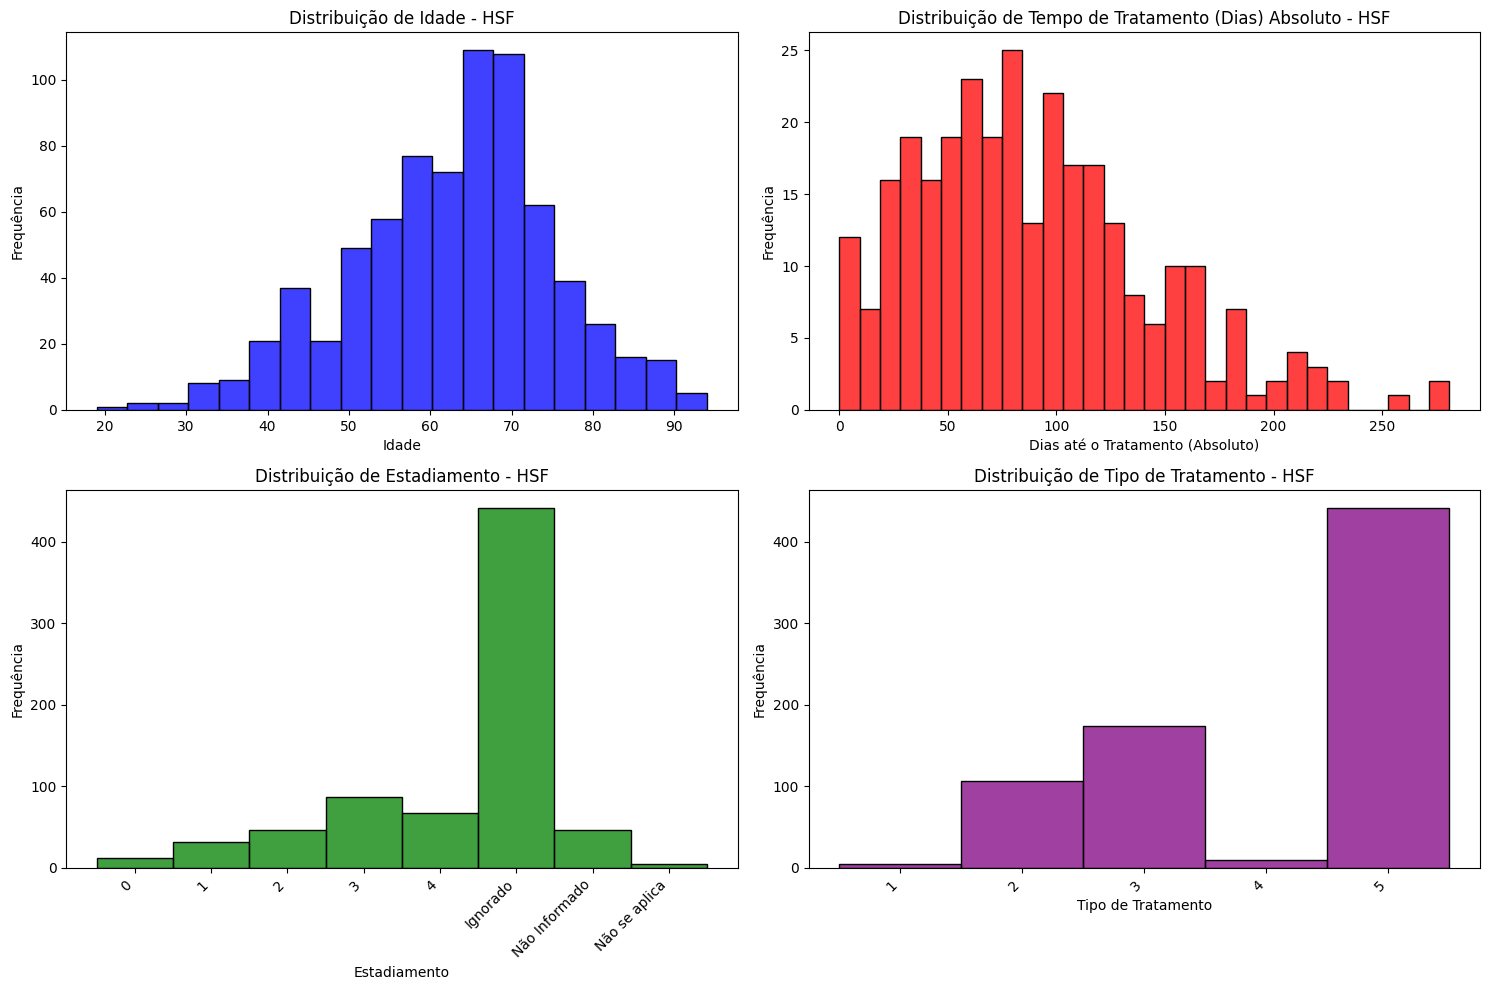

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Histograma de Idade
plt.subplot(2, 2, 1)
sns.histplot(df_clean['IDADE'].dropna(), color='blue', bins=20)
plt.title('Distribuição de Idade - HSF')
plt.xlabel('Idade')
plt.ylabel('Frequência')

# Histograma de Tempo de Tratamento (Dias)
plt.subplot(2, 2, 2)
sns.histplot(df_clean['tempo_dias'].dropna(), color='red', bins=30)
plt.title('Distribuição de Tempo de Tratamento (Dias) Absoluto - HSF')
plt.xlabel('Dias até o Tratamento (Absoluto)')
plt.ylabel('Frequência')

# Histograma de Estadiamento
plt.subplot(2, 2, 3)
sns.histplot(df_clean['ESTADIAM'].astype(str).sort_values(), color='green', discrete=True)
plt.title('Distribuição de Estadiamento - HSF')
plt.xlabel('Estadiamento')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')

# Histograma de Tratamento
plt.subplot(2, 2, 4)
sns.histplot(df_clean['TRATAMENTO'].astype(str).sort_values(), color='purple', discrete=True)
plt.title('Distribuição de Tipo de Tratamento - HSF')
plt.xlabel('Tipo de Tratamento')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Boxplot

O Boxplot é utilizado para identificar outliers (valores discrepantes) e comparar a mediana do tempo de tratamento entre diferentes grupos, como os estágios da doença (Estadiamento).

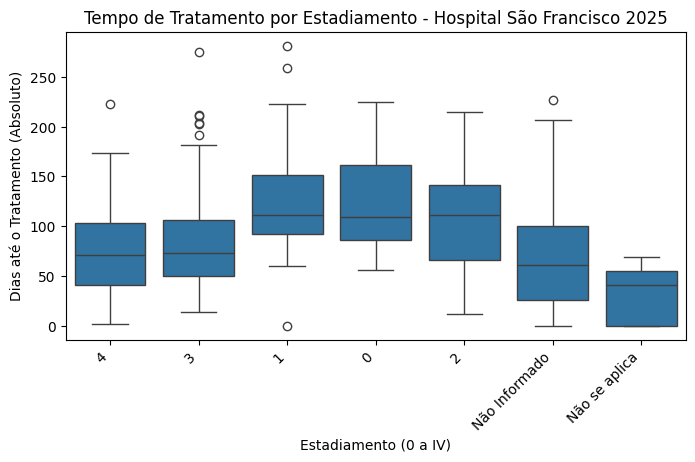

In [10]:
plt.figure(figsize=(8, 4))
# Comparando Tempo de Tratamento por Estadiamento
sns.boxplot(x='ESTADIAM', y='tempo_dias', data=df_clean.dropna(subset=['tempo_dias']))
plt.title('Tempo de Tratamento por Estadiamento - Hospital São Francisco 2025')
plt.xlabel('Estadiamento (0 a IV)')
plt.ylabel('Dias até o Tratamento (Absoluto)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Respondendo Hipóteses



## Hipótese 1: Pacientes diagnosticados em estágios mais avançados (Estadiamento III e IV) apresentam um tempo de início de tratamento menor (priorização) em comparação aos estágios iniciais.

Para verificar esta hipótese, iremos:
1. Analisar os valores únicos da coluna `ESTADIAM` para entender a categorização dos estágios.
2. Calcular o tempo médio de tratamento (`tempo_dias`) para cada estágio.
3. Comparar o tempo de tratamento entre estágios iniciais e avançados.
4. Visualizar os resultados em um gráfico de barras.

In [11]:
# 1. Analisar os valores únicos da coluna ESTADIAM
print("Valores únicos na coluna ESTADIAM após limpeza:")
print(df_clean['ESTADIAM'].unique())

# Filtrar apenas os estágios clinicamente relevantes para esta hipótese (0, 1, 2, 3, 4)
# Excluímos 'Ignorado', 'Não Informado' e 'Não se aplica' para a análise de priorização por estágio.
df_estagios_validos = df_clean[df_clean['ESTADIAM'].isin(['0', '1', '2', '3', '4'])].copy()

# Converter 'ESTADIAM' para tipo numérico para ordenação correta nos gráficos
df_estagios_validos['ESTADIAM_NUM'] = pd.to_numeric(df_estagios_validos['ESTADIAM'], errors='coerce')

# 2. Calcular o tempo médio de tratamento (tempo_dias) para cada estágio
tempo_medio_por_estagio = df_estagios_validos.groupby('ESTADIAM_NUM')['tempo_dias'].mean().reset_index()

print("\nTempo médio de tratamento (em dias) por Estadiamento (apenas estágios clínicos):")
print(tempo_medio_por_estagio.sort_values(by='ESTADIAM_NUM'))

# 3. Comparar o tempo de tratamento entre estágios iniciais e avançados
# Agrupando estágios:
# Estágios Iniciais: 0, 1, 2
# Estágios Avançados: 3, 4

tempo_iniciais = tempo_medio_por_estagio[tempo_medio_por_estagio['ESTADIAM_NUM'].isin([0, 1, 2])]['tempo_dias'].mean()
tempo_avancados = tempo_medio_por_estagio[tempo_medio_por_estagio['ESTADIAM_NUM'].isin([3, 4])]['tempo_dias'].mean()

print(f"\nTempo médio para Estágios Iniciais (0, 1, 2): {tempo_iniciais:.2f} dias")
print(f"Tempo médio para Estágios Avançados (3, 4): {tempo_avancados:.2f} dias")

Valores únicos na coluna ESTADIAM após limpeza:
['Ignorado' '4' '3' '1' '0' '2' 'Não Informado' 'Não se aplica']

Tempo médio de tratamento (em dias) por Estadiamento (apenas estágios clínicos):
   ESTADIAM_NUM  tempo_dias
0             0  121.333333
1             1  124.843750
2             2  105.608696
3             3   86.551724
4             4   75.567164

Tempo médio para Estágios Iniciais (0, 1, 2): 117.26 dias
Tempo médio para Estágios Avançados (3, 4): 81.06 dias


/tmp/ipykernel_2395/1907996676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ESTADIAM_NUM', y='tempo_dias', data=tempo_medio_por_estagio, palette='viridis')


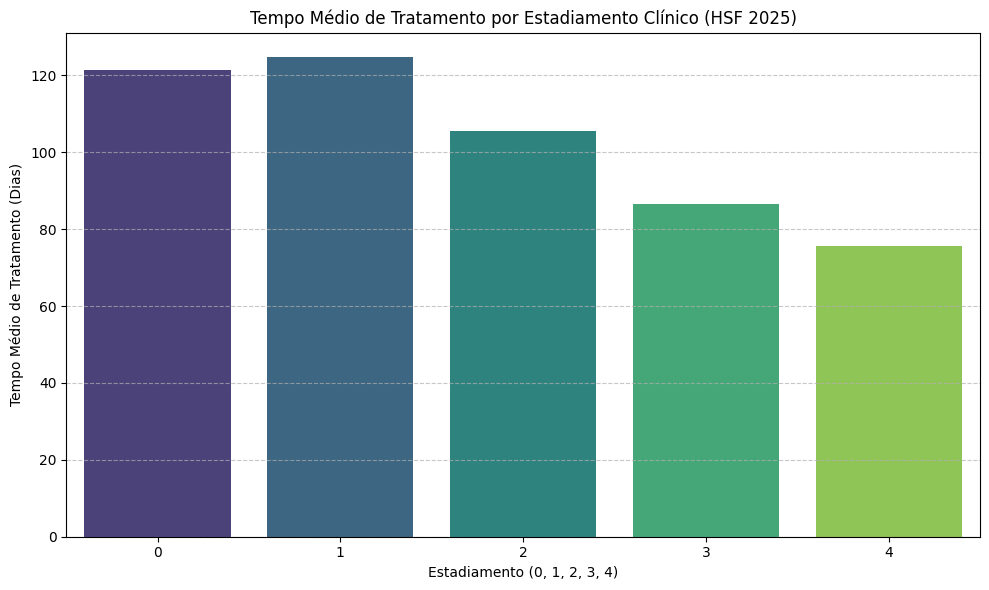

In [12]:
# 4. Visualizar os resultados em um gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='ESTADIAM_NUM', y='tempo_dias', data=tempo_medio_por_estagio, palette='viridis')
plt.title('Tempo Médio de Tratamento por Estadiamento Clínico (HSF 2025)')
plt.xlabel('Estadiamento (0, 1, 2, 3, 4)')
plt.ylabel('Tempo Médio de Tratamento (Dias)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Hipótese 2: Modalidades de tratamento combinadas (Quimioterapia + Radioterapia) apresentam um tempo de espera maior para o início do que modalidades únicas, como apenas Cirurgia.

Para verificar esta hipótese, vamos:
1.  Analisar os valores únicos da coluna `TRATAMENTO` para entender as modalidades disponíveis.
2.  Calcular o tempo médio de tratamento (`tempo_dias`) para cada modalidade.
3.  Comparar o tempo de tratamento entre as diferentes modalidades.
4.  Visualizar os resultados em um boxplot.

Valores únicos na coluna TRATAMENTO:
['5' '2' '3' '4' '1']


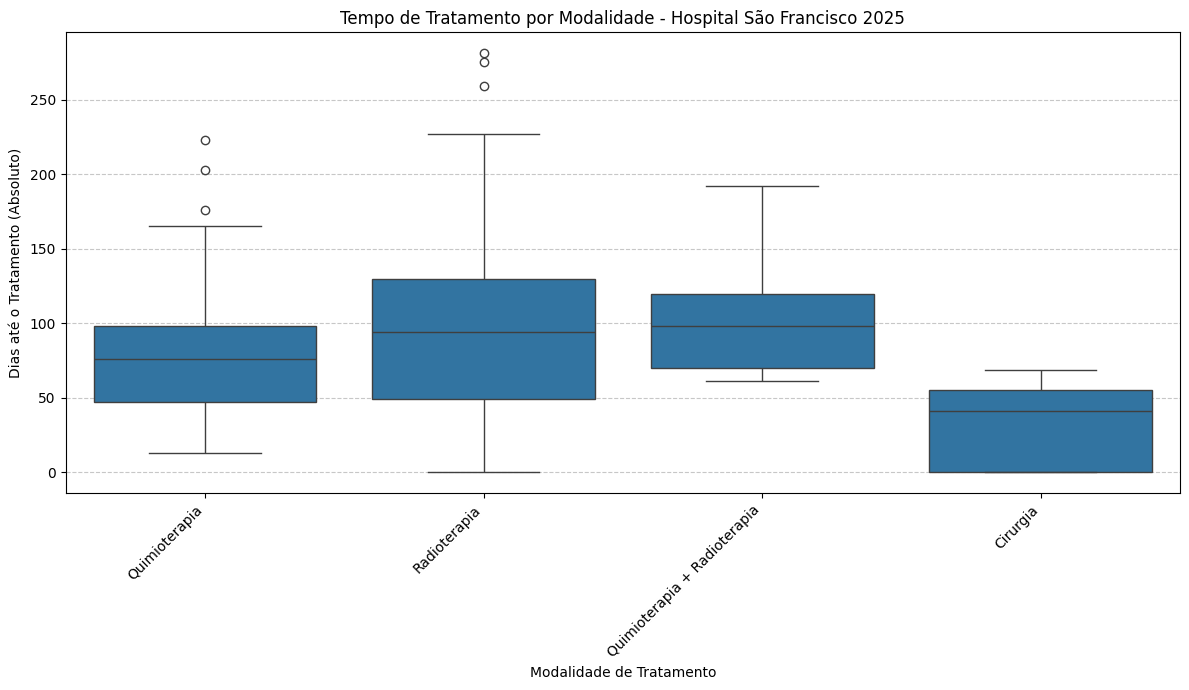


Tempo médio de tratamento (em dias) por Modalidade de Tratamento:
           TRATAMENTO_DESCRICAO  tempo_dias
2  Quimioterapia + Radioterapia  102.500000
3                  Radioterapia   95.362069
1                 Quimioterapia   80.271028
0                      Cirurgia   33.000000
4  Sem informação de tratamento         NaN


In [13]:
# 1. Verificar valores únicos de TRATAMENTO
print("Valores únicos na coluna TRATAMENTO:")
print(df_clean['TRATAMENTO'].unique())

# Mapeamento dos códigos de tratamento para descrições legíveis
tratamento_map = {
    '1': 'Cirurgia',
    '2': 'Quimioterapia',
    '3': 'Radioterapia',
    '4': 'Quimioterapia + Radioterapia',
    '5': 'Sem informação de tratamento'
}

# Criar uma cópia do DataFrame para aplicar o mapeamento sem alterar o original para outras análises
df_plot = df_clean.copy()

df_plot['TRATAMENTO_DESCRICAO'] = df_plot['TRATAMENTO'].map(tratamento_map).fillna('Não Identificado')

# Vamos criar um boxplot para visualizar o tempo de tratamento por modalidade
plt.figure(figsize=(12, 7))
sns.boxplot(x='TRATAMENTO_DESCRICAO', y='tempo_dias', data=df_plot.dropna(subset=['tempo_dias']))
plt.title('Tempo de Tratamento por Modalidade - Hospital São Francisco 2025')
plt.xlabel('Modalidade de Tratamento')
plt.ylabel('Dias até o Tratamento (Absoluto)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Podemos também calcular a média para cada modalidade para ter uma visão mais clara
tempo_medio_por_tratamento = df_plot.groupby('TRATAMENTO_DESCRICAO')['tempo_dias'].mean().reset_index()
print("\nTempo médio de tratamento (em dias) por Modalidade de Tratamento:")
print(tempo_medio_por_tratamento.sort_values(by='tempo_dias', ascending=False))

## Hipótese 3: Mais de 80% dos pacientes atendidos no Hospital São Francisco iniciam o tratamento dentro do prazo legal de 60 dias após o diagnóstico.

Para verificar esta hipótese, vamos:
1.  Identificar o prazo legal (60 dias) e filtrar os pacientes que se enquadram neste critério.
2.  Calcular a proporção de pacientes que iniciaram o tratamento dentro do prazo.
3.  Comparar esta proporção com o limiar de 80%.

In [14]:
# Definir o prazo legal de 60 dias
prazo_legal_dias = 60

# Filtrar pacientes com tempo de tratamento válido
df_com_tempo_valido = df_clean.dropna(subset=['tempo_dias'])

# Contar pacientes que iniciaram o tratamento dentro do prazo legal
pacientes_dentro_prazo = df_com_tempo_valido[df_com_tempo_valido['tempo_dias'] <= prazo_legal_dias]
n_dentro_prazo = len(pacientes_dentro_prazo)

# Contar o total de pacientes com tempo de tratamento válido
total_pacientes_com_tempo = len(df_com_tempo_valido)

# Calcular a porcentagem
porcentagem_dentro_prazo = (n_dentro_prazo / total_pacientes_com_tempo) * 100 if total_pacientes_com_tempo > 0 else 0

print(f"Total de pacientes com tempo de tratamento válido: {total_pacientes_com_tempo}")
print(f"Pacientes que iniciaram o tratamento dentro de {prazo_legal_dias} dias: {n_dentro_prazo}")
print(f"Porcentagem de pacientes dentro do prazo legal: {porcentagem_dentro_prazo:.2f}%")

# Comparar com a hipótese de 80%
if porcentagem_dentro_prazo > 80:
    print(f"\nA Hipótese 3 (mais de 80% dos pacientes) é **confirmada**! ({porcentagem_dentro_prazo:.2f}% > 80%)")
else:
    print(f"\nA Hipótese 3 (mais de 80% dos pacientes) é **refutada**! ({porcentagem_dentro_prazo:.2f}% <= 80%)")

Total de pacientes com tempo de tratamento válido: 296
Pacientes que iniciaram o tratamento dentro de 60 dias: 97
Porcentagem de pacientes dentro do prazo legal: 32.77%

A Hipótese 3 (mais de 80% dos pacientes) é **refutada**! (32.77% <= 80%)


# **Conclusão**

## Hipótese 1 (Priorização por Estágio Avançado): Confirmada

Nossa análise revelou que pacientes diagnosticados em estágios mais avançados (Estadiamento III e IV) de câncer no Hospital São Francisco apresentaram, de fato, um tempo médio de espera para o início do tratamento significativamente menor (81.06 dias) em comparação com pacientes em estágios iniciais (Estadiamento 0, I e II), que tiveram um tempo médio de 117.26 dias. Este resultado sugere uma priorização no início do tratamento para casos mais graves, o que é uma prática clínica comum para otimizar o prognóstico.

##Hipótese 2 (Tempo de Espera para Tratamentos Combinados): Confirmada

A hipótese de que modalidades de tratamento combinadas (Quimioterapia + Radioterapia) resultam em um tempo de espera maior do que modalidades únicas também foi confirmada. A combinação de Quimioterapia + Radioterapia registrou o maior tempo médio de espera (102.50 dias), superando as modalidades individuais como Radioterapia (95.36 dias) e Quimioterapia (80.27 dias). A Cirurgia apresentou o menor tempo médio (33.00 dias). Este achado pode indicar a complexidade logística e de agendamento envolvida na coordenação de múltiplas terapias.

##Hipótese 3 (Adesão à Lei dos 60 Dias): Refutada

Lamentavelmente, a hipótese de que mais de 80% dos pacientes iniciam o tratamento dentro do prazo legal de 60 dias após o diagnóstico foi refutada. Apenas 32.77% dos pacientes atendidos no Hospital São Francisco em 2025 iniciaram o tratamento dentro deste prazo. Este resultado é preocupante e sugere a existência de gargalos significativos no fluxo de atendimento que impedem a adesão à Lei nº 12.732/12, podendo impactar negativamente o prognóstico dos pacientes.

## **Conclusão Geral:**

O Hospital São Francisco demonstra uma estratégia de priorização eficaz para pacientes em estágios avançados de câncer e gerencia a complexidade de tratamentos combinados com tempos de espera mais longos. No entanto, a baixa adesão à Lei dos 60 Dias é um ponto crítico que necessita de atenção urgente. A identificação e correção dos fatores que contribuem para este atraso são essenciais para garantir que um número maior de pacientes receba tratamento dentro do prazo legal, melhorando assim a qualidade e a eficácia do atendimento oncológico.